# 🛌 Sleep Health and Lifestyle Analysis

This notebook explores how various lifestyle and physiological factors—such as sleep duration, stress, physical activity, and heart rate—relate to sleep health and potential sleep disorders. The dataset contains anonymized data collected from individuals across different occupations and age groups.

#### Ignore warnings

In [1]:
# Suppresses all warning messages for cleaner output
import warnings
warnings.filterwarnings("ignore")

## 📥 Load and Preview Dataset

We begin by loading the dataset, which includes features such as age, occupation, sleep patterns, physical activity, and several health indicators.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from termcolor import colored


In [4]:
df1 = pd.read_csv("raw_data/Sleep_health_and_lifestyle_dataset.csv")

## 🔍 Exploratory Data Analysis (EDA)

In this section, we explore the structure, types, and summary statistics of the dataset to understand potential relationships between variables and detect any issues like missing values or inconsistencies.

### 📊 Dataset Overview

Before jumping into deeper EDA, we examine the dataset's structure, including column names, data types, and descriptive statistics. We also apply light formatting to spot standout numeric values quickly.

In [5]:
df = df1.copy()

In [6]:
# first peek before EDA
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [7]:
# sanity check on column headers
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [8]:
# replace spaces with underscores for cleaner column referencing
df.columns = df.columns.str.replace(' ', '_')

In [9]:
# check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    object 
 9   Blood_Pressure           374 non-null    object 
 10  Heart_Rate               374 non-null    int64  
 11  Daily_Steps              374 non-null    int64  
 12  Sleep_Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [10]:
# summary of numerical columns — range, central tendency, spread
df.describe()

,Person_ID,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [11]:
# styling summary stats to quickly spot standout values
round(df.describe(exclude = 'object'), 2).style.background_gradient(cmap='BuPu')

,Person_ID,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.180000,7.130000,7.310000,59.170000,5.390000,70.170000,6816.840000
std,108.110000,8.670000,0.800000,1.200000,20.830000,1.770000,4.140000,1617.920000
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [12]:
# stats of categorical data
round (df.describe(exclude = ['float', 'int64']),2)

,Gender,Occupation,BMI_Category,Blood_Pressure,Sleep_Disorder
count,374,374,374,374,155
unique,2,11,4,25,2
top,Male,Nurse,Normal,130/85,Sleep Apnea
freq,189,73,195,99,78


#### 🧩 Missing Values Review

The only column with missing values (`null`) is **Sleep_Disorder**. However, these are not truly missing — they simply represent individuals without a diagnosed sleep condition.  
To maintain clarity and avoid misinterpretation during modeling, we will replace `null` with `"None"` in the **Data Cleaning** section.

In [13]:
# checking for missing values to prepare for cleaning
df.isnull().sum()

Person_ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep_Duration               0
Quality_of_Sleep             0
Physical_Activity_Level      0
Stress_Level                 0
BMI_Category                 0
Blood_Pressure               0
Heart_Rate                   0
Daily_Steps                  0
Sleep_Disorder             219
dtype: int64

### 🧮 Frequency Distribution

We explore how values are distributed across several categorical and ordinal features using `value_counts()`. This helps spot dominant values, class balance, and formatting issues.

Note: `Blood_Pressure` values appear as strings in the format "systolic/diastolic".

In [14]:
# checking distribution of blood pressure entries (formatted as strings)
df.Blood_Pressure.value_counts()

Blood_Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
132/87     3
128/85     3
126/83     2
115/78     2
139/91     2
142/92     2
119/77     2
135/88     2
129/84     2
128/84     2
131/86     2
117/76     2
130/86     2
118/75     2
121/79     1
122/80     1
118/76     1
Name: count, dtype: int64

In [15]:
# checking gender distribution (roughly balanced)
df.Gender.value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [16]:
# inspecting occupation frequencies — may need grouping for modeling
df.Occupation.value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [17]:
# checking distribution of sleep quality scores
df.Quality_of_Sleep.value_counts()

Quality_of_Sleep
8    109
6    105
7     77
9     71
5      7
4      5
Name: count, dtype: int64

In [18]:
# checking reported physical activity levels
df.Physical_Activity_Level.value_counts()

Physical_Activity_Level
60    70
30    68
45    68
75    67
90    67
40     6
55     6
35     4
50     4
70     3
42     2
32     2
80     2
65     2
85     2
47     1
Name: count, dtype: int64

In [19]:
# checking reported stress levels
df.Stress_Level.value_counts()

Stress_Level
3    71
8    70
4    70
5    67
7    50
6    46
Name: count, dtype: int64

### 🧼 Data cleaning

#### 🔧 Fixing Inconsistent BMI Labels

After cleaning, the `"Normal"` category now has 216 entries, up from 195, confirming label consolidation.

In [20]:
# checking initial distribution and missing values in Sleep_Disorder
df.BMI_Category.value_counts()

BMI_Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [21]:
df['BMI_Category'] = df['BMI_Category'].replace({'Normal Weight': 'Normal'})

In [22]:
df.BMI_Category.value_counts()

BMI_Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

#### 🔧 Filling Missing Values in Sleep Disorder

In [23]:
# checking initial distribution and missing values in Sleep_Disorder
df.Sleep_Disorder.value_counts()

Sleep_Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [24]:
df.Sleep_Disorder.isna().sum()

np.int64(219)

In [25]:
df['Sleep_Disorder'] = df['Sleep_Disorder'].fillna('None')

In [26]:
df.Sleep_Disorder.value_counts()

Sleep_Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

### Data Visualization

#### 📌 General Pairwise Plot (Optional Overview)


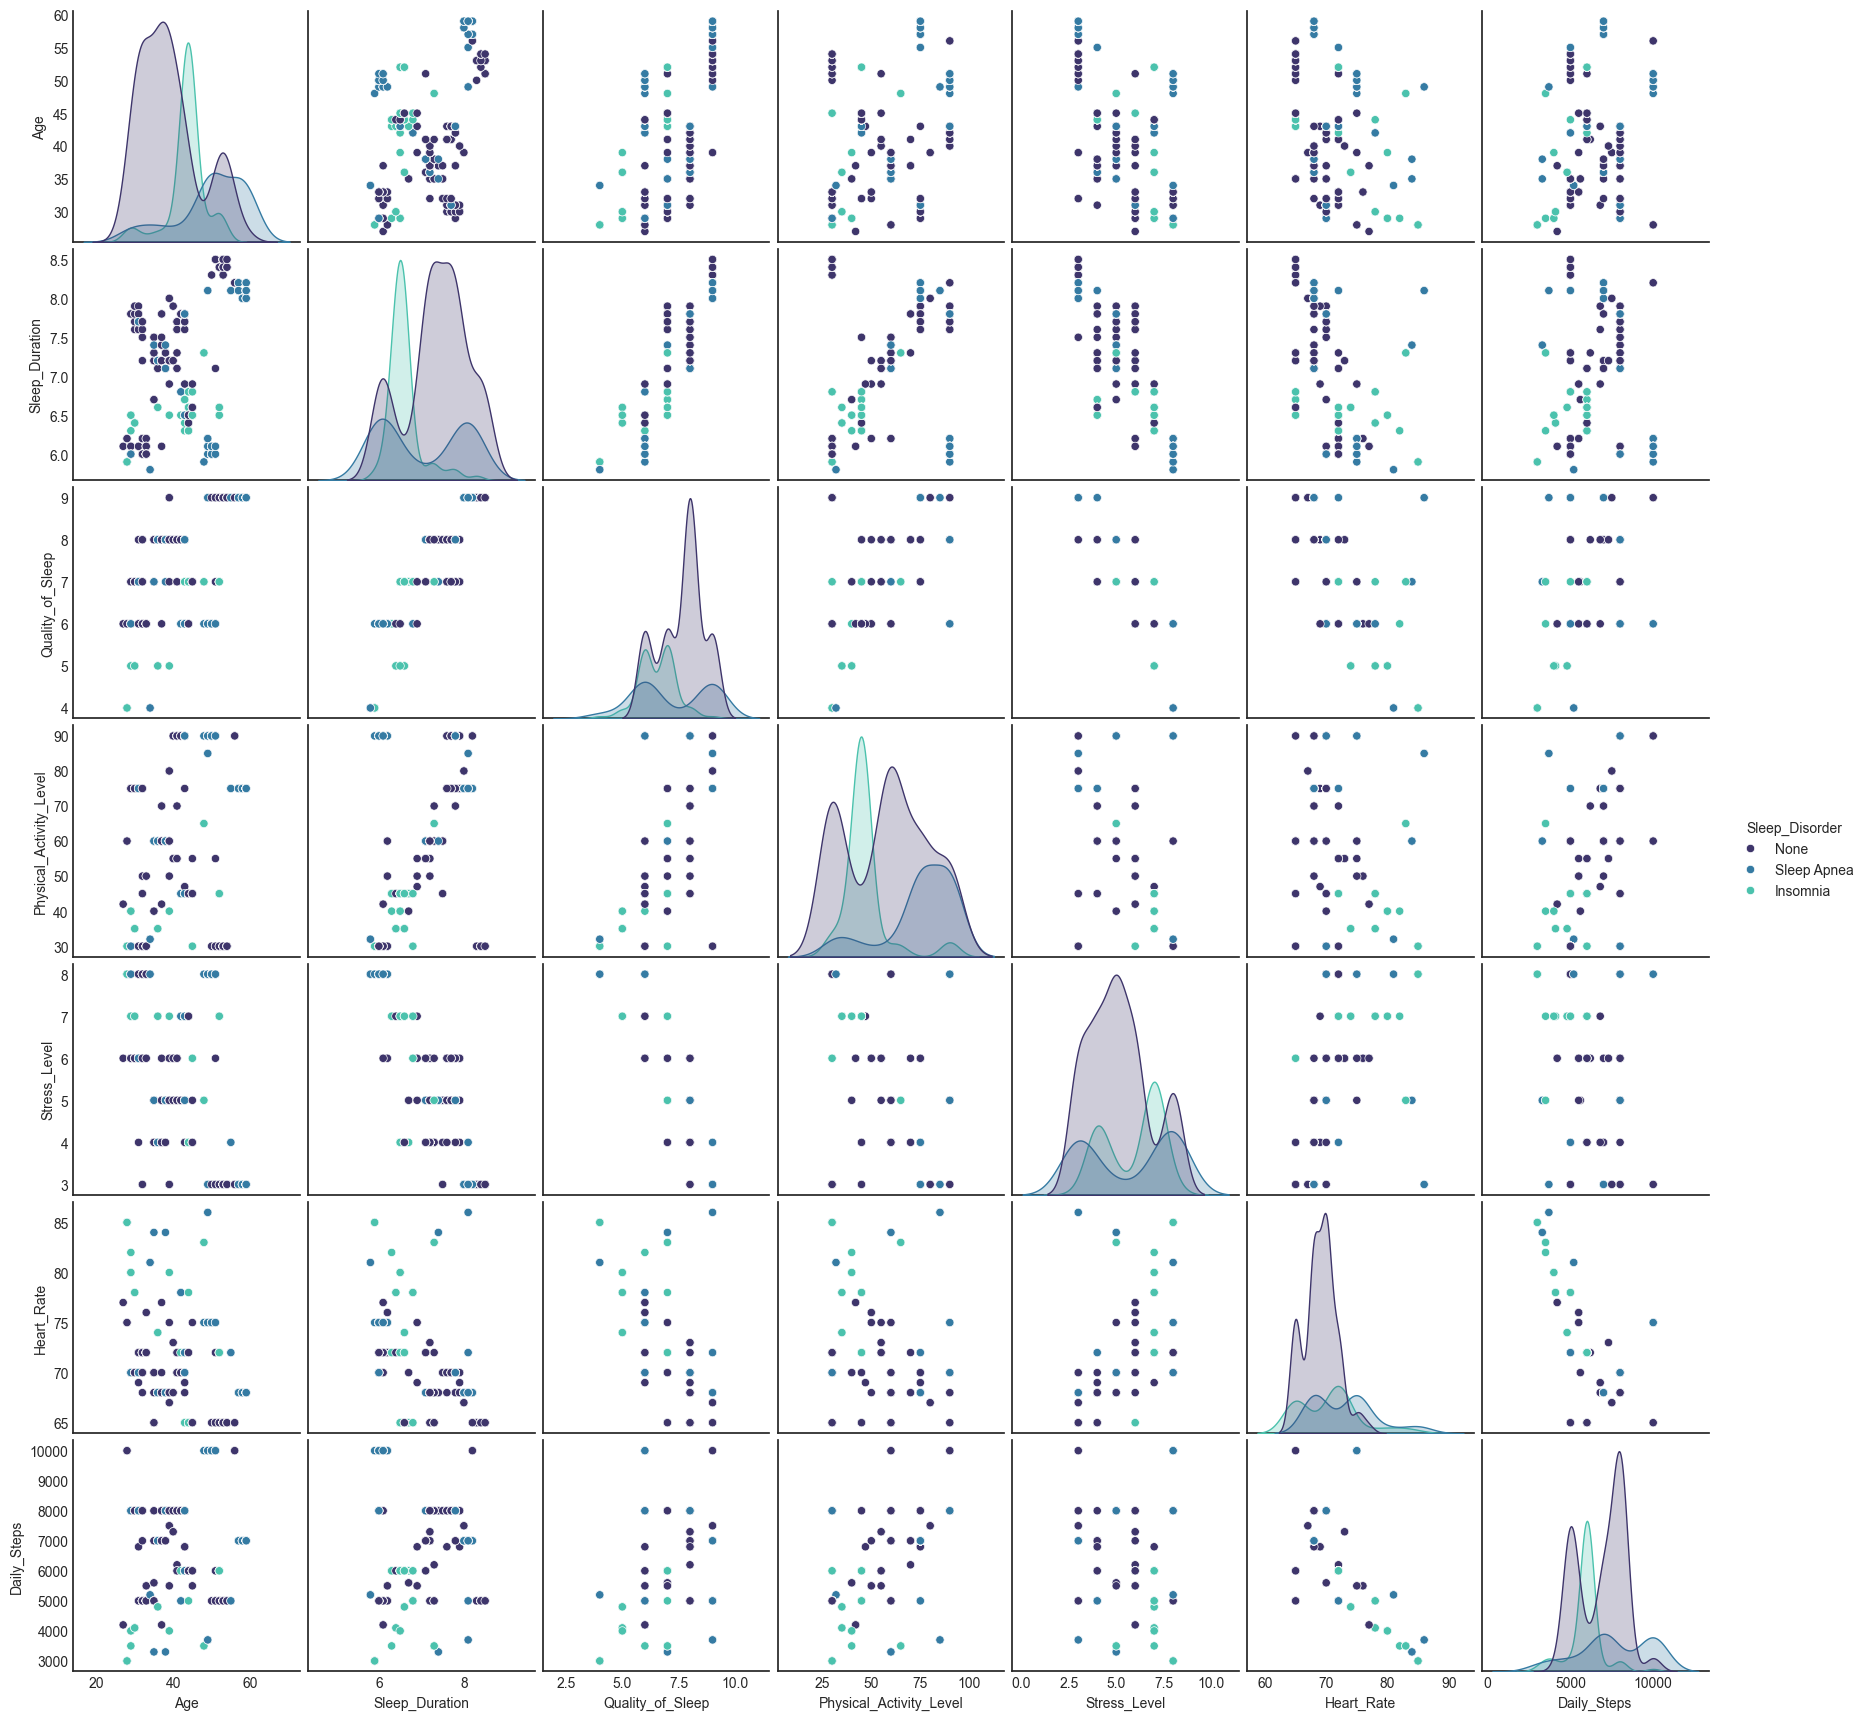

In [27]:
plt.style.use('seaborn-v0_8-white')
sns.pairplot(data=df.drop('Person_ID', axis=1),  hue='Sleep_Disorder', palette ='mako' )
plt.legend()
plt.show()

#### 💭 General Sleep Disorder Distribution

This donut chart shows the percentage of individuals with and without sleep disorders in the dataset.

In [28]:
df2=df.drop(['Person_ID'], axis=1)

In [29]:
# Calculate the count for each sleep disorder category
sleep_counts = df2['Sleep_Disorder'].value_counts().reset_index()
sleep_counts.columns = ['Sleep_Disorder', 'Count']

# Calculate the percentage for each category
sleep_counts['Percentage'] = sleep_counts['Count'] / sleep_counts['Count'].sum() * 100


fig = px.pie(
    sleep_counts, 
    values='Count', 
    names='Sleep_Disorder',
    title='Percentage of Persons by Sleep Disorder Status',
    hole=0.5,  # Converts the pie chart to a donut chart
    color='Sleep_Disorder',
  
    color_discrete_map={
        'None': '#4DA6FF',       
        'Sleep Apnea': '#A569BD',  
        'Insomnia': '#FF6F61'
})

# Customize the text inside the donut: shows both label and percentage
fig.update_traces(
    textposition='inside', 
    textinfo='percent+label',
    hovertemplate='%{label}: %{percent:.2%}<extra></extra>'
)


fig.update_layout(
    margin=dict(t=50, b=50, l=50, r=50),
    font=dict(size=14),
    width=700, 
    height=700 
)

fig.show()


#### 📌 Is Sleep Disorder Distribution Different Between Genders?

While the overall number of males and females in the dataset is nearly equal, Females have a higher prevalence of Sleep Apnea, while males are more likely to report no sleep disorder.
 Insomnia rates are relatively similar across both genders.

In [30]:
sleep_df = df2.groupby(['Gender', 'Sleep_Disorder']).size().reset_index(name='Count')

fig = px.bar(
    sleep_df,
    x="Gender",
    y="Count",
    color="Sleep_Disorder",
    title="Gender and Sleep Disorder Breakdown",
    barmode="stack",
    color_discrete_map={  
        'None': '#4DA6FF',       
        'Sleep Apnea': '#A569BD',  
        'Insomnia': '#FF6F61'      
    }
)


fig.update_layout(
    margin=dict(t=50, b=50, l=50, r=50),
    font=dict(size=14),
    width=700, 
    height=700 
)
fig.show()

#### 📊 Correlation Heatmap: Numerical Features

Key correlations highlighted: stress vs. sleep, and activity vs. steps.

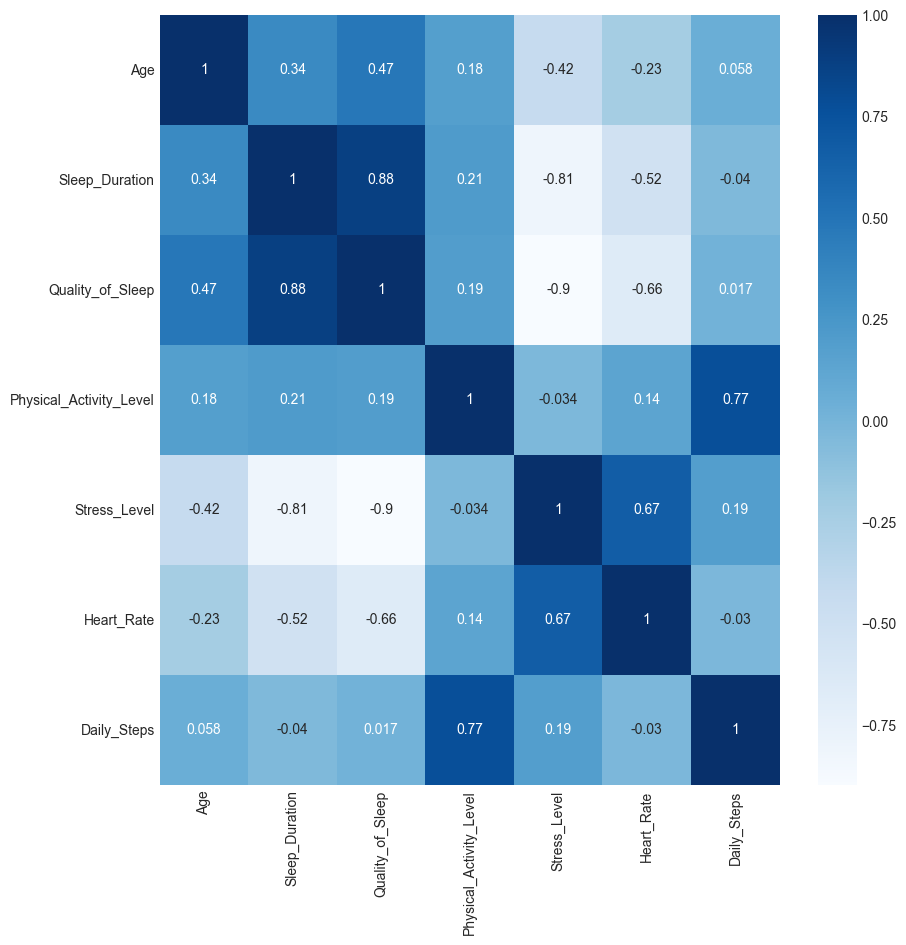

In [31]:
numeric_df = df2.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues');

#### 📌 Do Sleep Disorders Lead to Higher Stress?

This highlights a strong association between sleep disorders and elevated stress levels, particularly in Sleep Apnea cases.


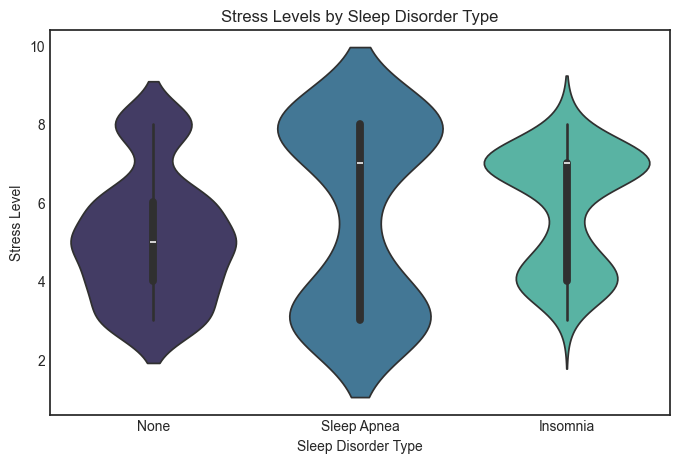

In [32]:
# Visualizing how stress levels vary across different sleep disorder types
plt.figure(figsize=(8, 5))
sns.violinplot(data=df2, x='Sleep_Disorder', y='Stress_Level', palette='mako')
plt.title("Stress Levels by Sleep Disorder Type")
plt.xlabel("Sleep Disorder Type")
plt.ylabel("Stress Level")
plt.show()


#### 📌 Does sleeping for long periods necessarily mean higher quality sleep?

Longer sleep duration is generally associated with better sleep quality, but the relationship is not strictly linear. Some individuals sleep for longer periods but still report low sleep quality, suggesting that factors like stress or sleep disorders may play a more significant role in determining sleep quality than just duration alone.

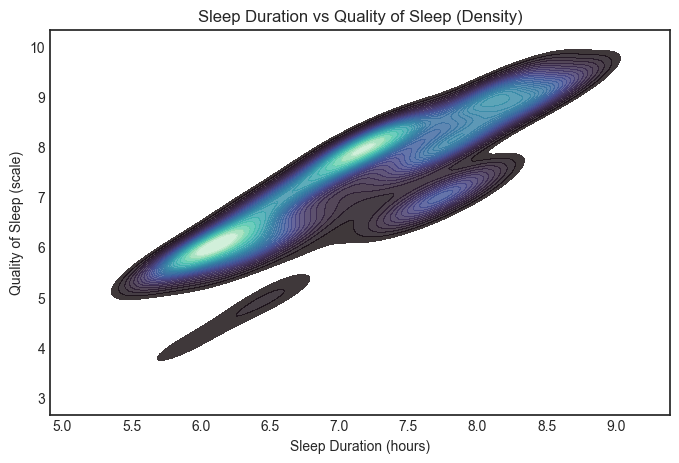

In [33]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df2, x='Sleep_Duration', y='Quality_of_Sleep', 
            fill=True, cmap='mako', levels=30, alpha=0.8)
plt.title("Sleep Duration vs Quality of Sleep (Density)")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Quality of Sleep (scale)")
plt.show()

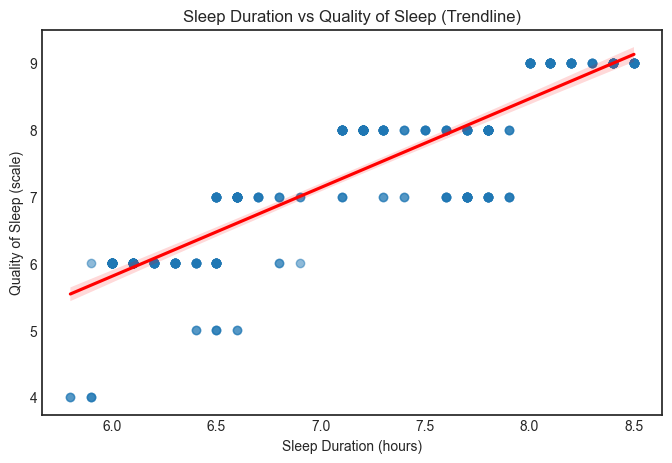

In [34]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df2, x='Sleep_Duration', y='Quality_of_Sleep', scatter=True, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ci=95)
plt.title("Sleep Duration vs Quality of Sleep (Trendline)")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Quality of Sleep (scale)")
plt.show()

#### 📌 Does Stress Affect Sleep Quality in a Linear Way?

Stress does impact sleep quality, but the relationship is not linear. Individuals with lower stress levels tend to enjoy both longer and higher-quality sleep. As stress increases, both duration and quality become more fragmented and inconsistent.
Other variables like lifestyle and disorder type may further mediate this relationship.


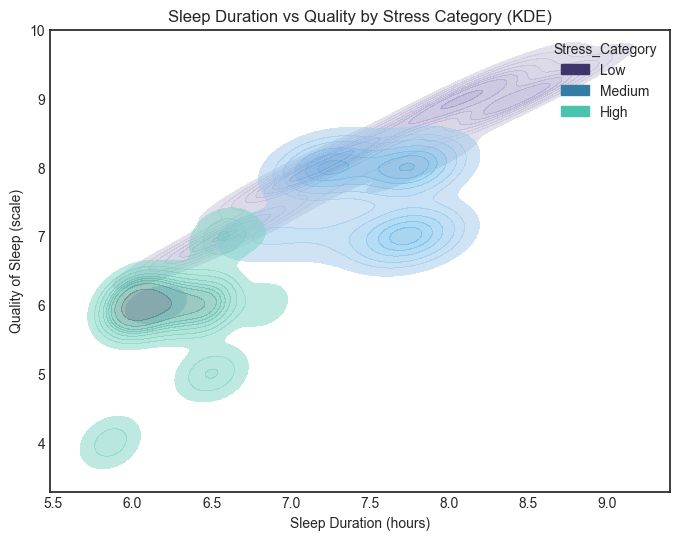

In [35]:
# Divide Stress_Level into categories: Low, Medium, High
df2['Stress_Category'] = pd.qcut(df2['Stress_Level'], q=3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(8, 6))

sns.kdeplot(data=df2, x='Sleep_Duration', y='Quality_of_Sleep', 
            hue='Stress_Category', fill=True, palette='mako', alpha=0.5)

plt.title("Sleep Duration vs Quality by Stress Category (KDE)")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Quality of Sleep (scale)")

plt.show()

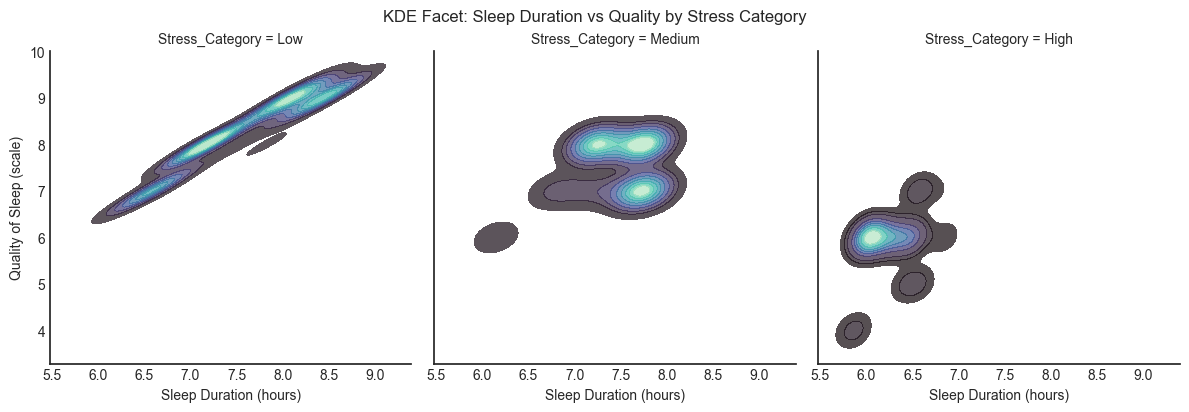

In [36]:
g = sns.FacetGrid(df2, col="Stress_Category", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.kdeplot, x="Sleep_Duration", y="Quality_of_Sleep", fill=True, cmap='mako', alpha=0.7)

g.set_axis_labels("Sleep Duration (hours)", "Quality of Sleep (scale)")
g.fig.suptitle("KDE Facet: Sleep Duration vs Quality by Stress Category", y=1.02)
plt.show()

 #### 📌 Does Walking More Increase Physical Activity Level?


There’s a clear positive correlation between daily steps and physical activity level. Individuals who walk more frequently tend to show higher activity scores, confirming that consistent movement throughout the day contributes significantly to physical activity.

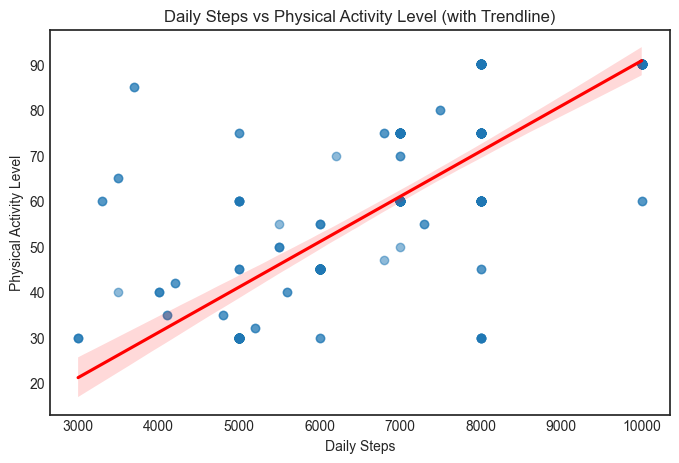

In [37]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df2, x='Daily_Steps', y='Physical_Activity_Level', scatter=True, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ci=95)
plt.title("Daily Steps vs Physical Activity Level (with Trendline)")
plt.xlabel("Daily Steps")
plt.ylabel("Physical Activity Level")
plt.show()

#### 📌 Does Higher Stress Lead to a Faster Heart Rate?

As stress levels increase, we generally observe a rise in heart rate. The box plot shows that individuals with higher stress levels tend to have higher median heart rates, along with increased variability. This suggests a possible physiological response to stress, although individual differences are evident and other contributing factors may be involved.


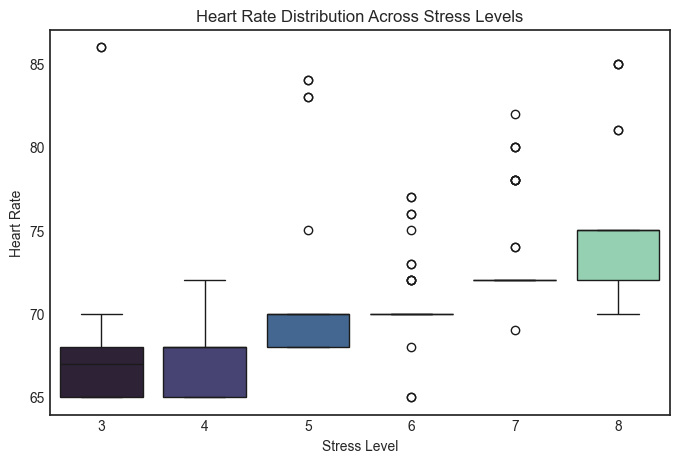

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df2, x='Stress_Level', y='Heart_Rate', palette='mako')
plt.title("Heart Rate Distribution Across Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Heart Rate")
plt.show()

#### 📌 Does Being More Active Improve Sleep Quality?

Individuals with higher physical activity levels tend to report better sleep quality. The plot shows that those with low activity levels have a wider spread in sleep quality scores, while those with higher activity levels show more consistent and higher-quality sleep. This pattern suggests a positive association between physical activity and sleep quality.


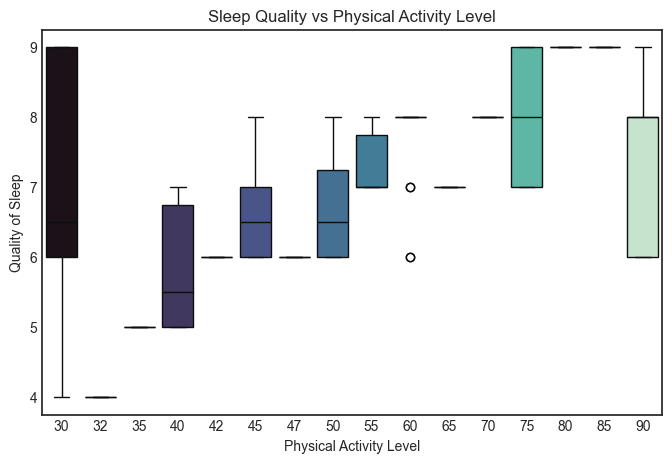

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df2, x='Physical_Activity_Level', y='Quality_of_Sleep', palette='mako')
plt.title("Sleep Quality vs Physical Activity Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Quality of Sleep")
plt.show()

#### 📌 Does Walking More Mean Sleeping Longer?

There appears to be no strong correlation between the number of daily steps and sleep duration. The scatter plot shows that individuals with similar step counts can have widely different sleep durations. This indicates that walking more does not necessarily translate to longer sleep.


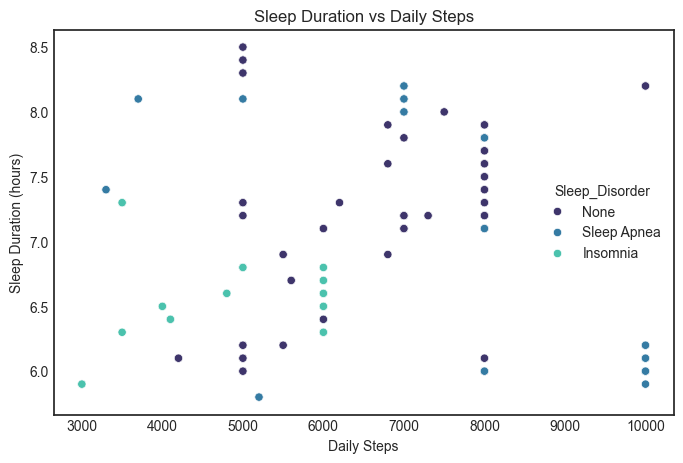

In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df2, x='Daily_Steps', y='Sleep_Duration', hue='Sleep_Disorder', palette='mako')
plt.title("Sleep Duration vs Daily Steps")
plt.xlabel("Daily Steps")
plt.ylabel("Sleep Duration (hours)")
plt.show()

####  📌 Is There a Clear Relationship Between Blood Pressure and Heart Rate?

The analysis reveals a weak positive correlation (0.29) between blood pressure categories and heart rate. While heart rate tends to increase slightly with higher blood pressure, the relationship isn’t strong enough to be considered a reliable indicator. Other factors like stress or physical activity may have a more significant impact on heart rate.


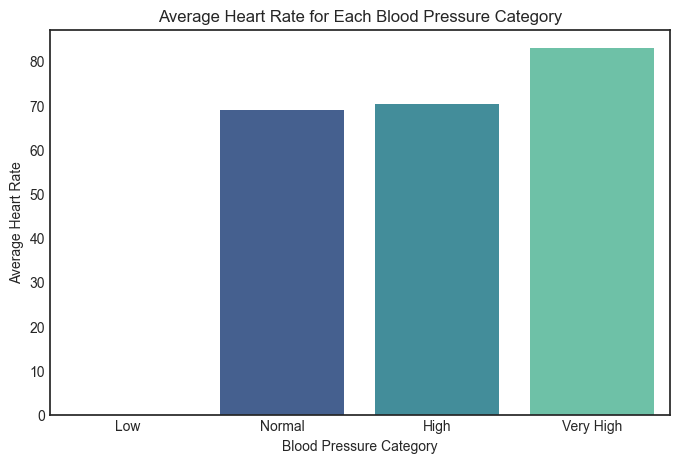

In [41]:
# Convert 'Blood_Pressure' to systolic values ​​only (before '/')
df2['Systolic_BP'] = df2['Blood_Pressure'].astype(str).str.split('/').str[0] 
df2['Systolic_BP'] = pd.to_numeric(df2['Systolic_BP'], errors='coerce')

#Dividing blood pressure into categories
bins = [80, 100, 120, 140, 180]  
labels = ['Low', 'Normal', 'High', 'Very High']
df2['BP_Category'] = pd.cut(df2['Systolic_BP'], bins=bins, labels=labels)

# Heart rate calculation for each category
bp_summary = df2.groupby('BP_Category')['Heart_Rate'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=bp_summary, x='BP_Category', y='Heart_Rate', palette='mako')
plt.title("Average Heart Rate for Each Blood Pressure Category")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Average Heart Rate")
plt.show()

In [42]:
correlation = df2[['Systolic_BP', 'Heart_Rate']].corr().iloc[0,1]
print(f"Correlation between Blood Pressure and Heart Rate: {correlation:.2f}")

Correlation between Blood Pressure and Heart Rate: 0.29


#### 📌 Is There a Significant Difference in Sleep Disorders Across Different Occupations?


There are clear occupation-based differences in sleep disorder prevalence. For instance, insomnia appears significantly more common among nurses, while doctors and engineers are more likely to report no sleep disorders. This indicates that job type may influence sleep health, potentially due to stress, schedules, or workload.


In [43]:
occupation_df = df2.groupby(['Occupation', 'Sleep_Disorder']).size().reset_index(name='Count')

fig = px.bar(
    occupation_df,
    x="Occupation",           
    y="Count",                
    color="Sleep_Disorder",   
    title="Occupation and Sleep Disorder Breakdown",  
    barmode="stack",          
    color_discrete_map={    
        'None': '#4DA6FF',       
        'Sleep Apnea': '#A569BD',  
        'Insomnia': '#FF6F61'      
    }
)

fig.update_layout(
    margin=dict(t=50, b=50, l=50, r=50),
    font=dict(size=14)
)

fig.show()


In [44]:
fig=px.treemap(df2,path=[px.Constant('Jobs'),'Sleep_Disorder','Occupation'],
               color='Sleep_Disorder',
 color_discrete_map={    
        'None': '#4DA6FF',       
        'Sleep Apnea': '#A569BD',  
        'Insomnia': '#FF6F61'      
    })

fig.update_layout(title='<b>Sleep Disorder Distribution by Occupation</b>',
                 title_font={'size':20},
    margin=dict(t=50, b=50, l=50, r=50),
    font=dict(size=14),
    width=700, 
    height=700 
)

fig.show()

#### 📌 Does Age Influence Sleep Disorders?

Age seems to play a role in sleep disorder prevalence. The ECDF plot shows that individuals without sleep disorders tend to be younger, while those with sleep apnea or insomnia are more common in older age brackets. This suggests a potential age-related increase in sleep-related issues.


In [45]:

fig = px.ecdf(df2, x='Age',
              color='Sleep_Disorder',
              color_discrete_map={    
                  'None': '#4DA6FF',       
                  'Sleep Apnea': '#A569BD',  
                  'Insomnia': '#FF6F61'      
              })

fig.update_layout(title="<b>Age Distribution by Sleep Disorder</b>",
                  title_font={'size': 25},
                  paper_bgcolor='#FFFFFF', 
                #   plot_bgcolor='#FFFFFF',
                
    margin=dict(t=50, b=50, l=50, r=50),
    font=dict(size=14),
    xaxis_title="Age",  
    yaxis_title="Cumulative Probability",  
    xaxis=dict(title_font=dict(size=18), tickfont=dict(size=14)), 
    yaxis=dict(title_font=dict(size=18), tickfont=dict(size=14)) 
)

fig.update_xaxes(showgrid=True, gridcolor='lightgray') 
fig.update_yaxes(showgrid=False)

fig.show()

## 🎯 Target-Oriented Analysis: Sleep Disorder

In this section, we focus on analyzing key variables in relation to the presence of sleep disorders. The objective is to uncover patterns and insights that may explain why some individuals experience sleep disorders while others do not. These findings are essential for identifying strong candidate features for future predictive modeling and feature selection.



Our findings revealed the following:

- **Stress Level**: Individuals with sleep apnea consistently show higher stress levels, with a wide variance in their responses.
- **Sleep Duration**: Those without sleep disorders tend to sleep longer on average, typically between 7–8 hours. In contrast, individuals with sleep disorders, especially insomnia, sleep less.
- **Sleep Quality**: The quality of sleep is significantly lower for individuals with disorders, particularly sleep apnea.
- **Activity Level**: Those without sleep disorders are also more physically active.

These insights suggest that stress, physical activity, and sleep duration are closely related to the presence of sleep disorders. These variables will likely serve as valuable predictors in the upcoming machine learning phase.


### 📦 Stress Level by Sleep Disorder Type

The boxplot below clearly illustrates a distinct difference in stress levels across the three sleep disorder categories. Individuals diagnosed with **Sleep Apnea** exhibit the highest levels of stress, with a broader range of values. Those without any diagnosed disorder (`None`) maintain relatively low and stable stress levels.



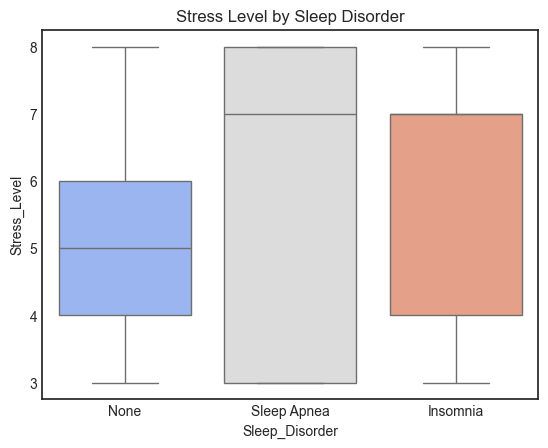

In [46]:
sns.boxplot(x="Sleep_Disorder", y="Stress_Level", data=df2, palette="coolwarm")
plt.title("Stress Level by Sleep Disorder");

### 💤 Sleep Duration Distribution by Disorder

The histogram and KDE plot show that individuals without sleep disorders typically report **7–8 hours of sleep**. In contrast, those with **Insomnia** or **Sleep Apnea** tend to sleep **less**, mostly in the **5–6 hour range**. This trend suggests a negative relationship between sleep duration and the likelihood of a disorder.


<Axes: xlabel='Sleep_Duration', ylabel='Count'>

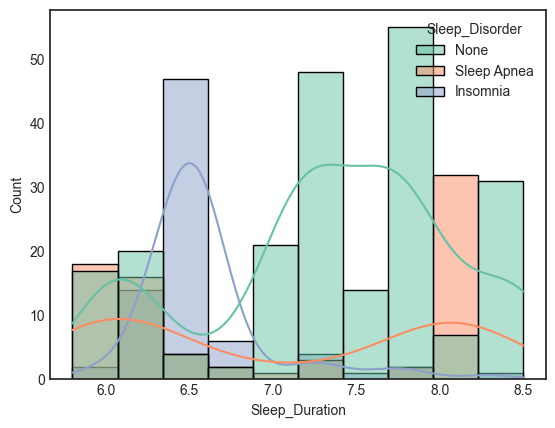

In [47]:
sns.histplot(data=df2, x="Sleep_Duration", hue="Sleep_Disorder", kde=True, palette="Set2")

### 📉 Sleep Quality by Disorder

The violin plot below highlights the disparity in **sleep quality** among the groups. Individuals with **Sleep Apnea** report the lowest sleep quality, while those with **Insomnia** also show lower-than-average ratings. In contrast, those without any sleep disorder report higher and more consistent sleep quality scores.


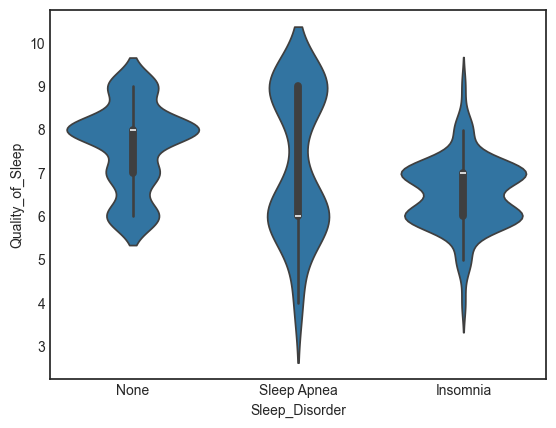

In [48]:
sns.violinplot(x="Sleep_Disorder", y="Quality_of_Sleep", data=df2);

### 📊 Grouped Statistics: Sleep Duration, Stress, and Activity

These statistical differences highlight the importance of considering multiple lifestyle and physiological variables when modeling sleep disorder prediction. It becomes evident that individuals with sleep disorders not only sleep less and report poorer quality of sleep but also show lower levels of physical activity and higher stress.

In [49]:
df.groupby("Sleep_Disorder")[["Sleep_Duration", "Stress_Level", "Physical_Activity_Level"]].mean()

,Sleep_Duration,Stress_Level,Physical_Activity_Level
Sleep_Disorder,,,
Insomnia,6.589610,5.870130,46.818182
None,7.358447,5.114155,57.949772
Sleep Apnea,7.032051,5.666667,74.794872


### 📈 Correlation with Sleep Quality (Sleep Disorder Group)

To identify the most relevant factors linked to **sleep quality** among individuals with sleep disorders, we computed the correlation matrix for numeric features.

---

**Top Correlated Features:**
- **Sleep_Duration**: Strong positive correlation (**+0.91**) – longer sleep = better quality.
- **Stress_Level**: Strong negative correlation (**-0.87**) – higher stress = worse sleep.
- **Age**: Moderate positive correlation (**+0.71**).
- **Heart_Rate**: Moderate negative correlation (**-0.53**).
- Other variables (e.g. steps, blood pressure) showed weak correlations.

---

These results confirm that **sleep duration** and **stress level** are key indicators of sleep quality. Both will be prioritized as features in the upcoming model.

Text(0.5, 1.0, 'Correlation Matrix: Individuals with Sleep Disorders Only')

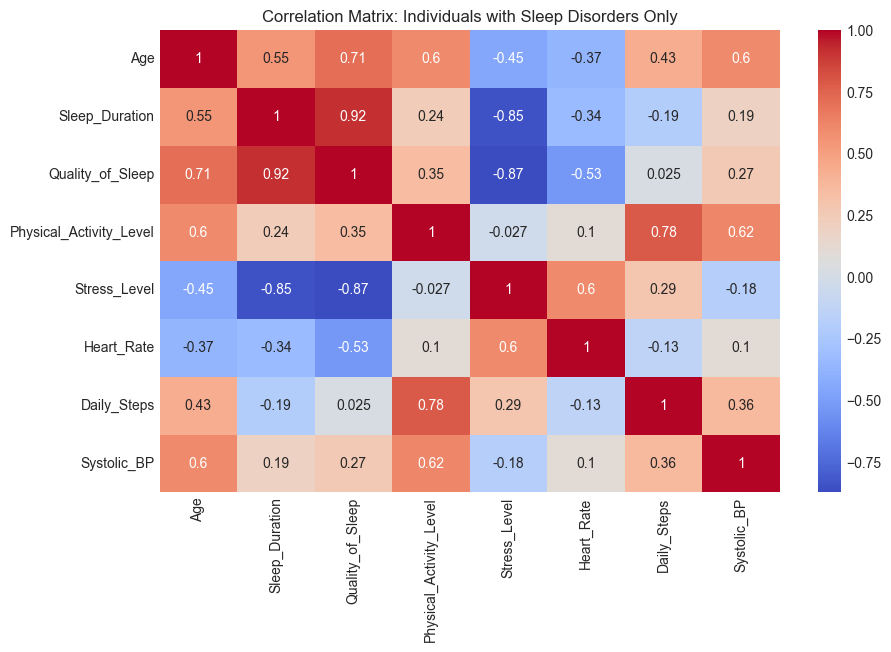

In [50]:

# Filter data where disorder is NOT 'None'
disorder_df2 = df2[df2['Sleep_Disorder'] != 'None']
plt.figure(figsize=(10,6))
sns.heatmap(disorder_df2.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix: Individuals with Sleep Disorders Only")


In [51]:
numeric_corr = disorder_df2.select_dtypes(include='number').corr()
correlation_with_target = numeric_corr["Quality_of_Sleep"].sort_values(ascending=False)
print(correlation_with_target)

Quality_of_Sleep           1.000000
Sleep_Duration             0.916748
Age                        0.710221
Physical_Activity_Level    0.352021
Systolic_BP                0.265830
Daily_Steps                0.025166
Heart_Rate                -0.534720
Stress_Level              -0.872084
Name: Quality_of_Sleep, dtype: float64


## 📊 Statistical Testing: Validating Observations


In this section, we apply statistical tests to verify whether the patterns observed in the exploratory analysis are statistically significant. This helps ensure that the insights we found are not just due to random chance and can be confidently used for modeling.

#### 📌 Does Sleep Quality Significantly Differ Across Sleep Disorder Types?

To validate whether the observed differences in sleep quality across sleep disorder types are statistically meaningful, we conducted a **one-way ANOVA** test.

###  One-way ANOVA
#### 🧪 Hypotheses:
- **H₀**: The mean sleep quality is the same across all sleep disorder groups.
- **H₁**: At least one group has a significantly different mean sleep quality.

#### ✅ Result:
- **F-statistic**: 27.60  
- **P-value**: < 0.001

Since the p-value is far below 0.05, we **reject the null hypothesis**.  
This confirms that sleep disorder type has a **statistically significant impact** on sleep quality.


F-statistic: 27.601
P-value: 0.0000


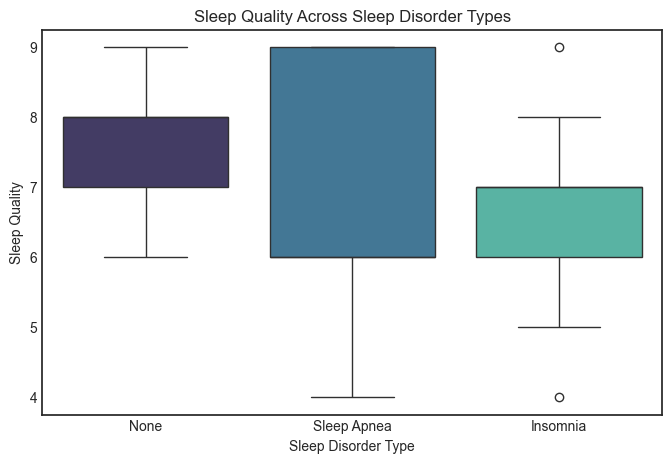

In [52]:
# Filter numeric target variable for each group
none_quality = df2[df2['Sleep_Disorder'] == 'None']['Quality_of_Sleep']
apnea_quality = df2[df2['Sleep_Disorder'] == 'Sleep Apnea']['Quality_of_Sleep']
insomnia_quality = df2[df2['Sleep_Disorder'] == 'Insomnia']['Quality_of_Sleep']

# Perform one-way ANOVA
f_stat, p_value = f_oneway(none_quality, apnea_quality, insomnia_quality)

# Display result
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Optional: visualize with boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Sleep_Disorder', y='Quality_of_Sleep', data=df2, palette='mako')
plt.title("Sleep Quality Across Sleep Disorder Types")
plt.xlabel("Sleep Disorder Type")
plt.ylabel("Sleep Quality")
plt.show()

#### 🧪 Chi-Square Test: Categorical Associations with Sleep Disorder

To check if categorical features are significantly associated with sleep disorder status, we performed a **Chi-Square test of independence**.  
This helps identify whether the distribution of sleep disorders varies meaningfully across categories.

##### 🧬 Features Tested
We tested the following categorical features:
- `Gender`
- `Occupation`
- `BMI_Category`

##### 🔍 Key Insight  
All tested features showed **statistically significant** associations (*p* < 0.05), indicating their potential relevance for classification models.


In [53]:
from scipy.stats import chi2_contingency

# Features to test
categorical_cols = ['Gender', 'Occupation', 'BMI_Category']

# Store results
chi_results = []

for col in categorical_cols:
    contingency = pd.crosstab(df2[col], df2['Sleep_Disorder'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p,
        'DoF': dof
    })

chi_df = pd.DataFrame(chi_results)
chi_df.sort_values(by='p-value')

,Feature,Chi2,p-value,DoF
1,Occupation,421.362755,7.481314e-77,20
2,BMI_Category,245.665344,5.588351e-52,4
0,Gender,54.306020,1.612863e-12,2



##### 📊 Visualization
The following bar chart shows how strongly each categorical feature is associated with sleep disorder status, based on its Chi-Square statistic.
Higher values suggest a stronger relationship.

In [54]:
# Sort Chi2 descending
chi_df_sorted = chi_df.sort_values(by='Chi2', ascending=False)

fig = px.bar(
    chi_df.sort_values(by='Chi2'),
    x='Chi2',
    y='Feature',
    orientation='h',
    text='p-value',
    color='Feature',
    color_discrete_sequence=['#40A6FF', '#A569BD', '#FF6F61'],
    title='Chi-Square Statistic by Feature'
)

fig.update_layout(
    title_font=dict(size=18),
    xaxis_title='Chi-Square Value',
    yaxis_title='',
    height=450,
    plot_bgcolor='white',
    bargap=0.4,
    margin=dict(t=80, b=50, l=50, r=50),
    showlegend=False
)

fig.update_traces(
    marker_line_color='black',
    marker_line_width=1.2,
    texttemplate='%{text:.2e}',
    textposition='outside'
)

fig.show()

## 🧰 Data Preparation: Encoding & Scaling

### 🧠 Encoding Categorical Features

We used label encoding for binary features and one-hot encoding for multi-class categories.


In [55]:
# Target column
target_col = 'Sleep_Disorder'

# Features (remove target)
X = df2.drop(columns=[target_col])
y = df2[target_col]

# Define categorical columns
nominal_cols = ['Gender', 'Occupation', 'Blood_Pressure']
ordinal_cols = ['BMI_Category', 'Stress_Category', 'BP_Category']

# Define order for ordinal features
ordinal_mapping = [
    ['Underweight', 'Normal', 'Overweight', 'Obese'],       # BMI_Category
    ['Low', 'Medium', 'High', 'Very High'],                 # Stress_Category 
    ['Normal', 'High', 'Very High']                         # BP_Category
]

# Nominal pipeline
nominal_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal pipeline
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_mapping))
])

# Column transformer
encoder = ColumnTransformer(transformers=[
    ('nominal', nominal_pipeline, nominal_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols)
], remainder='passthrough')  # to keep numeric columns

# Fit + transform features
X_encoded = encoder.fit_transform(X)

# Get feature names
encoded_col_names = (
    encoder.named_transformers_['nominal']
           .named_steps['onehot']
           .get_feature_names_out(nominal_cols).tolist()
    + ordinal_cols
    + X.drop(columns=nominal_cols + ordinal_cols).columns.tolist()
)

X_encoded = pd.DataFrame(X_encoded, columns=encoded_col_names)

# Encode the target column separately
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

In [56]:
X_encoded.head()

,Gender_Female,Gender_Male,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,...,Stress_Category,BP_Category,Age,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,Heart_Rate,Daily_Steps,Systolic_BP
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,27.0,6.1,6.0,42.0,6.0,77.0,4200.0,126.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,28.0,6.2,6.0,60.0,8.0,75.0,10000.0,125.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,28.0,6.2,6.0,60.0,8.0,75.0,10000.0,125.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.0,1.0,28.0,5.9,4.0,30.0,8.0,85.0,3000.0,140.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2.0,1.0,28.0,5.9,4.0,30.0,8.0,85.0,3000.0,140.0


### 📏 Feature Scaling

To standardize numerical features, we apply **z-score normalization** using `StandardScaler`.  
This ensures all features have a mean of 0 and standard deviation of 1 — which helps improve model performance, especially for distance-based and gradient-based algorithms.


In [57]:
# Define numerical columns to scale
numeric_cols = [
    'Age', 'Sleep_Duration', 'Quality_of_Sleep',
    'Physical_Activity_Level', 'Stress_Level',
    'Heart_Rate', 'Daily_Steps'
]

# Initialize and apply scaler
scaler = StandardScaler()
X_encoded[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

# check result
X_encoded[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,374.0,-3.799694e-16,1.00134,-1.753096,-0.800608,0.094153,0.902324,1.941401
Sleep_Duration,374.0,1.136108e-14,1.00134,-1.676439,-0.921335,0.085471,0.840575,1.721530
Quality_of_Sleep,374.0,2.849770e-16,1.00134,-2.771424,-1.098280,-0.261708,0.574864,1.411435
Physical_Activity_Level,374.0,-4.274655e-17,1.00134,-1.402260,-0.681208,0.039844,0.760896,1.481948
Stress_Level,374.0,6.649464e-17,1.00134,-1.345836,-0.781551,-0.217265,0.911306,1.475592
Heart_Rate,374.0,-1.358391e-15,1.00134,-1.250750,-0.524383,-0.040138,0.444107,3.833820
Daily_Steps,374.0,-9.974196e-17,1.00134,-2.362273,-0.753114,0.113356,0.732263,1.970077


## 🤖 Modeling: Predicting Sleep Disorders

### 📦 Train-Test Split
We split the dataset into training and testing sets to evaluate model performance on unseen data.


In [58]:

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# Optional: Check shape
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 299
Testing samples: 75


### 🤖 Logistic Regression

Used as a starting point to evaluate model performance.  
Multiclass setting with accuracy on training and testing sets.

In [59]:
# Initialize and fit the model
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lr_model.fit(X_train, y_train)

# Accuracy
train_score = lr_model.score(X_train, y_train)
test_score = lr_model.score(X_test, y_test)

# Fancy display
train_score_display = colored(f"{train_score*100:.2f}%", "magenta", attrs=["bold"])
test_score_display = colored(f"{test_score*100:.2f}%", "magenta", attrs=["bold"])

print(f"📊 Logistic Regression - Training Accuracy: {train_score_display}")
print(f"📊 Logistic Regression - Testing Accuracy:  {test_score_display}")

📊 Logistic Regression - Training Accuracy: 91.97%
📊 Logistic Regression - Testing Accuracy:  94.67%


#### 📊 Confusion Matrix – Logistic Regression

- **None**: 100% correctly classified  
- **Insomnia**: 13/15 correct *(2 predicted as Sleep Apnea)*  
- **Sleep Apnea**: 15/17 correct *(1 as None, 1 as Insomnia)*

Model performs well, especially in detecting “None” cases.

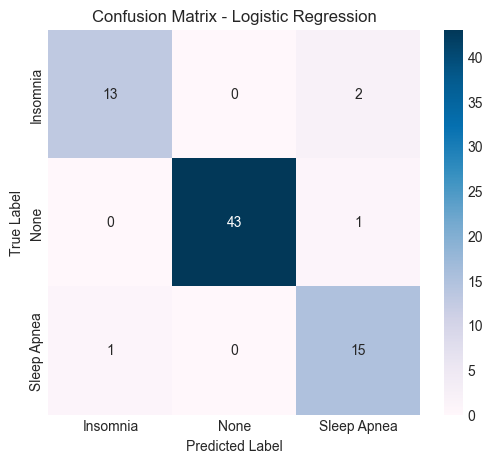

In [60]:
# Confusion Matrix 
y_pred = lr_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels = target_encoder.classes_  # assuming you encoded y using LabelEncoder

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### 🤖 Decision Tree Classifier

We now evaluate a **Decision Tree** model to classify sleep disorder types and compare its performance to the logistic regression baseline.

In [61]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Accuracy
dt_train_score = dt_model.score(X_train, y_train)
dt_test_score = dt_model.score(X_test, y_test)

# Display scores
print(colored(f"📊 Decision Tree - Training Accuracy: {dt_train_score*100:.2f}%", "cyan", attrs=["bold"]))
print(colored(f"📊 Decision Tree - Testing Accuracy:  {dt_test_score*100:.2f}%", "cyan", attrs=["bold"]))

📊 Decision Tree - Training Accuracy: 92.64%
📊 Decision Tree - Testing Accuracy:  93.33%


#### 📊 **Confusion Matrix – Decision Tree**

- **None:** 42/44 correctly classified (1 as Insomnia, 1 as Sleep Apnea)  
- **Insomnia:** 13/15 correct (2 predicted as Sleep Apnea)  
- **Sleep Apnea:** 15/16 correct (1 as Insomnia)  

Model performs well overall, with minor misclassifications between Insomnia and Sleep Apnea.

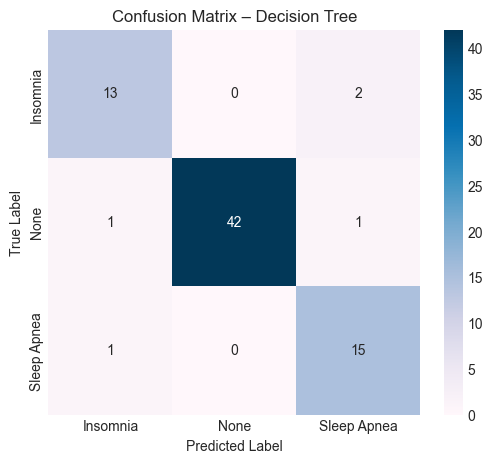

In [62]:
# Predict
y_pred_dt = dt_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
labels = target_encoder.classes_

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

###  🤖 Random Forest Classifier 


In [63]:
from sklearn.ensemble import RandomForestClassifier


# Initialize and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Accuracy scores
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

from termcolor import colored
train_display = colored(f"{train_acc*100:.2f}%", "magenta", attrs=["bold"])
test_display = colored(f"{test_acc*100:.2f}%", "magenta", attrs=["bold"])

print(f"📊 Random Forest - Training Accuracy: {train_display}")
print(f"📊 Random Forest - Testing Accuracy:  {test_display}")

📊 Random Forest - Training Accuracy: 92.64%
📊 Random Forest - Testing Accuracy:  92.00%


#### 📊 Confusion Matrix – Random Forest

- **None**: 43/44 correctly classified  
- **Insomnia**: 13/15 correct (2 predicted as Sleep Apnea)  
- **Sleep Apnea**: 13/16 correct (3 predicted as Insomnia)  

Model performs strongly overall, especially in detecting "None" and "Insomnia" classes.

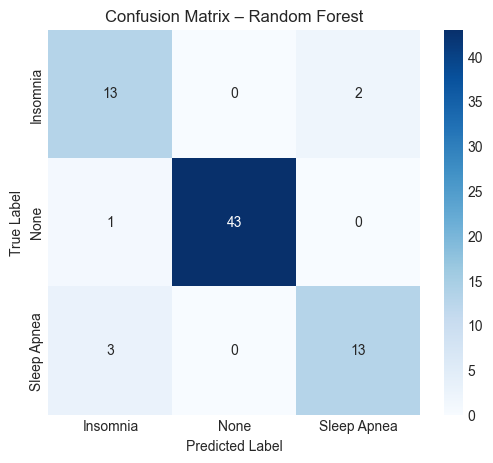

In [64]:
# Predictions
y_pred = rf_model.predict(X_test)
labels = target_encoder.classes_

# Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Random Forest")
plt.show()

### 🌀 Support Vector Classifier (SVC)


In [65]:
# 📌 SVC Model
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from termcolor import colored

# Initialize and train SVC model
svc_model = SVC(kernel='rbf', probability=True, random_state=42)
svc_model.fit(X_train, y_train)

# Accuracy scores
svc_train_acc = svc_model.score(X_train, y_train)
svc_test_acc = svc_model.score(X_test, y_test)

# Display scores
train_display = colored(f"{svc_train_acc*100:.2f}%", "magenta", attrs=["bold"])
test_display = colored(f"{svc_test_acc*100:.2f}%", "magenta", attrs=["bold"])
print(f"🌀  SVC - Training Accuracy: {train_display}")
print(f"🌀 SVC - Testing Accuracy:  {test_display}")


🌀  SVC - Training Accuracy: 58.53%
🌀 SVC - Testing Accuracy:  58.67%


#### 📉 Confusion Matrix – SVC  
- **None:** 44/44 correctly classified  
- **Insomnia:** 0/15 correct (all predicted as None)  
- **Sleep Apnea:** 0/16 correct (all predicted as None)  

Model heavily biases toward predicting the "None" class.

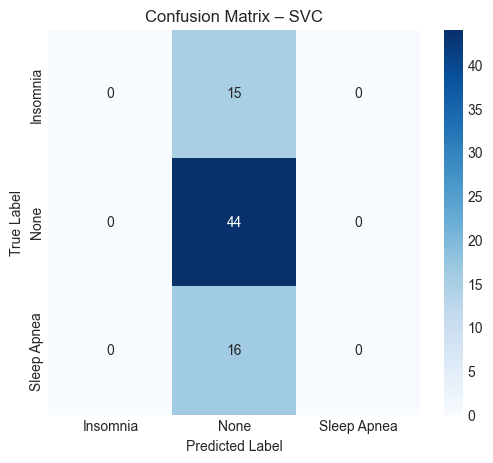

In [66]:
# Confusion matrix
svc_y_pred = svc_model.predict(X_test)
svc_cm = confusion_matrix(y_test, svc_y_pred)
labels = target_encoder.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(svc_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – SVC")
plt.show()


### 📘 KNeighborsClassifier - KNN

In [67]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and fit
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Accuracy
knn_train_acc = knn_model.score(X_train, y_train)
knn_test_acc = knn_model.score(X_test, y_test)

# Display
from termcolor import colored
train_display = colored(f"{knn_train_acc*100:.2f}%", "magenta", attrs=["bold"])
test_display = colored(f"{knn_test_acc*100:.2f}%", "magenta", attrs=["bold"])

print(f"📘 KNN - Training Accuracy: {train_display}")
print(f"📘 KNN - Testing Accuracy:  {test_display}")

📘 KNN - Training Accuracy: 89.97%
📘 KNN - Testing Accuracy:  96.00%


#### 📊 **Confusion Matrix – KNN**
- **None**: 44/44 correctly classified ✅  
- **Insomnia**: 12/15 correct (3 misclassified as Sleep Apnea)  
- **Sleep Apnea**: 16/16 correct ✅  

Model performs very well overall, especially in identifying **None** and **Sleep Apnea**. Minor confusion exists between **Insomnia** and **Sleep Apnea**.

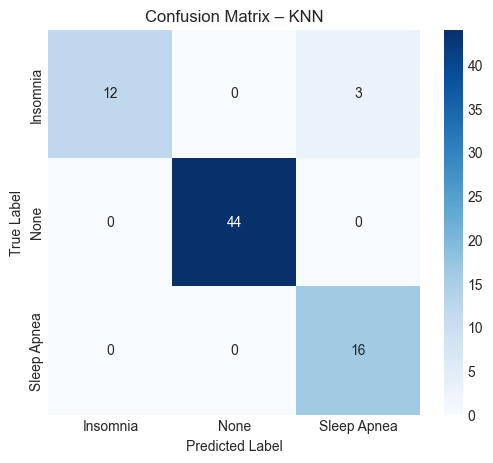

In [68]:
# 📊 Confusion Matrix
from sklearn.metrics import confusion_matrix
knn_y_pred = knn_model.predict(X_test)
knn_cm = confusion_matrix(y_test, knn_y_pred)
labels = target_encoder.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(knn_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – KNN")
plt.show()

### 🌲 Gradient Boosting Classifier

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

# Train the model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Accuracy
gb_train = gb_model.score(X_train, y_train)
gb_test = gb_model.score(X_test, y_test)

# Display accuracy
train_disp = colored(f"{gb_train*100:.2f}%", "magenta", attrs=["bold"])
test_disp = colored(f"{gb_test*100:.2f}%", "magenta", attrs=["bold"])

print(f"🌲 GB - Training Accuracy: {train_disp}")
print(f"🌲 GB - Testing Accuracy:  {test_disp}")

🌲 GB - Training Accuracy: 92.64%
🌲 GB - Testing Accuracy:  94.67%


#### 📊 Confusion Matrix – Gradient Boosting

- **None**: 43/44 correctly classified (1 misclassified as Insomnia)  
- **Insomnia**: 13/15 correct (2 predicted as Sleep Apnea)  
- **Sleep Apnea**: 15/16 correct (1 predicted as Insomnia)  

Model shows strong performance, especially for "None" and "Sleep Apnea" classes.

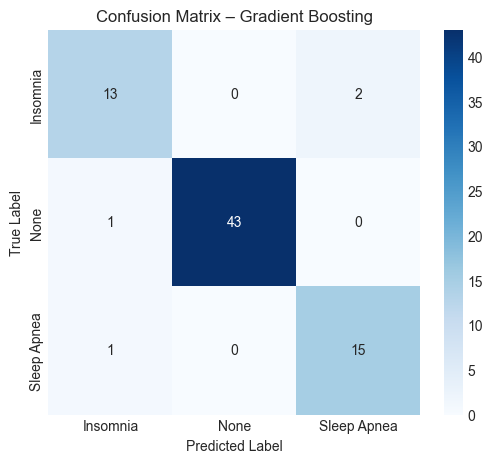

In [70]:
# Predict and plot
gb_pred = gb_model.predict(X_test)
labels = target_encoder.classes_
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Gradient Boosting")
plt.show()

### 🧠 XGBoost Classifier (Tuned with GridSearchCV)

In [77]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Basic parameter grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# Initialize model
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)

print("✅ Best Parameters:", grid_search.best_params_)
print(f"✅ Best Training Accuracy: {best_xgb.score(X_train, y_train):.2%}")
print(f"✅ Best Testing Accuracy:  {best_xgb.score(X_test, y_test):.2%}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
✅ Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
✅ Best Training Accuracy: 91.64%
✅ Best Testing Accuracy:  96.00%


#### 📊 **Confusion Matrix – Tuned XGBoost**  
- **None**: 44/44 correctly classified ✅  
- **Insomnia**: 13/15 correct (2 misclassified as Sleep Apnea)  
- **Sleep Apnea**: 15/16 correct (1 misclassified as Insomnia)  

Model shows excellent performance, achieving near-perfect classification.

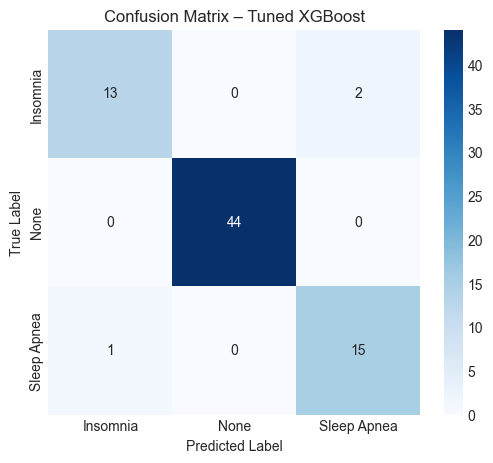

In [78]:
# 📊 Confusion Matrix for Tuned XGBoost

# Use the best estimator obtained from GridSearchCV
xgb_best = grid_search.best_estimator_

# Predict on test set
xgb_best_pred = xgb_best.predict(X_test)

# Get target class labels
labels = target_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_test, xgb_best_pred)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Tuned XGBoost")
plt.show()

#### 🔍 Feature Importance

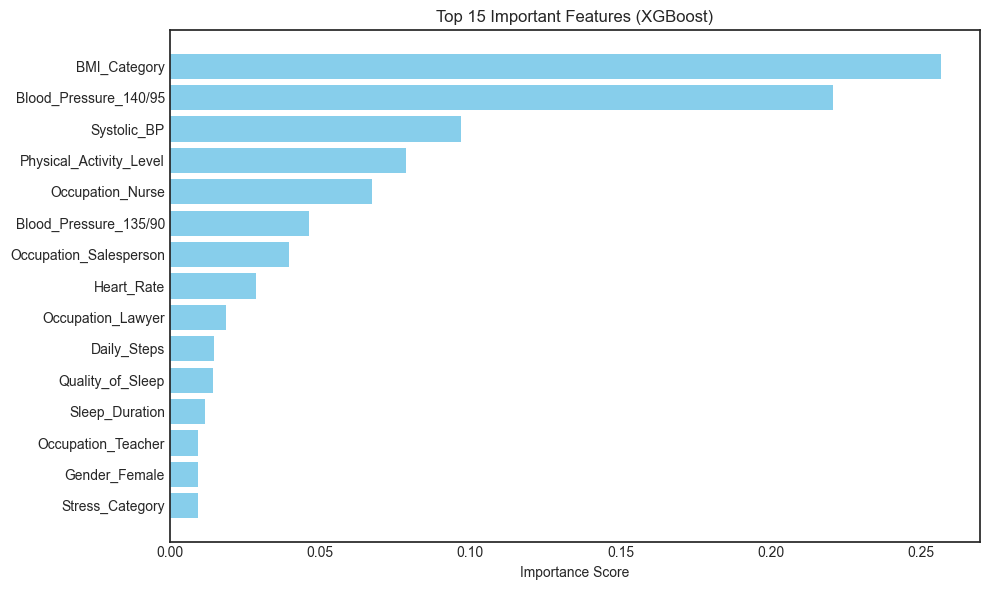

In [79]:
# Get feature importances
importances = xgb_best.feature_importances_
feature_names = X_encoded.columns

# Convert to DataFrame for sorting and plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top N features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:15][::-1], feat_imp_df['Importance'][:15][::-1], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Top 15 Important Features (XGBoost)")
plt.tight_layout()
plt.show()

## 💾 Saving the Trained Model

To reuse the best-performing model (Tuned XGBoost) in a future app or deployment, we export it using `pickle`.  
We also save the `LabelEncoder` to ensure consistent decoding of predicted classes during inference.

In [80]:
X = df2.drop(columns=["Sleep_Disorder"])
y = df2["Sleep_Disorder"]

best_xgb = XGBClassifier(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    use_label_encoder=False, 
    eval_metric="mlogloss"  
)
# Build full pipeline
final_pipeline = Pipeline([
    ('preprocessing', encoder),      # Your ColumnTransformer
    ('scaler', StandardScaler()),    # Scaling numerical features
    ('model', best_xgb)              # Best model (already trained)
])

# Fit the full pipeline
final_pipeline.fit(X, y_encoded)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Occupation',
                                                   'Blood_Pressure']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('ordinal',
                                                                   OrdinalEncoder(categories=[['Underweight',
                                                                                               'Normal',
                                                                                               'Overweight',
                                                                                               'Obese'],
                                                                                              ['Low',
                                                                                               'M...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [81]:
import pickle

# Save the trained XGBoost model
with open("model.pkl", "wb") as file:
    pickle.dump(final_pipeline, file)


In [82]:
# Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(target_encoder, f)